# Анализ клубной деятельности студентов

Этот notebook анализирует участие студентов в клубной деятельности вуза.

**Для обновления данных:**
1. Поместите новый CSV файл в папку `data/`
2. Обновите имя файла в переменной `DATA_FILE` ниже
3. Выполните все ячейки notebook (Run → Run All Cells)

In [ ]:
# Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Настройка отображения
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

## 1. Загрузка и подготовка данных

In [ ]:
# Имя файла с данными
DATA_FILE = '/content/dataset.csv'

# Общее количество студентов в вузе (обновите при необходимости)
TOTAL_STUDENTS_UNIVERSITY = 1677

# Загрузка данных
df = pd.read_csv(DATA_FILE)
print(f"Загружено записей: {len(df)}")
print(f"\nПервые 5 строк:")
df.head()

Загружено записей: 4763

Первые 5 строк:


,фио,username,role,club_name,event_name,event_id,is_attended,event_date
0,Глозман Леон Игоревич,V0LTA,student,Настольный клуб,«Пир призрачного герцога»,f15a0e46-4713-4d4b-a9c9-35743e355c05,False,2025-08-01 14:00:00.000000 +00:00
1,Фёдорова Анна Константиновна,anna2007fedorova,external_user,Настольный клуб,«Пир призрачного герцога»,f15a0e46-4713-4d4b-a9c9-35743e355c05,False,2025-08-01 14:00:00.000000 +00:00
2,Адюкова Мария Витальевна,hissikly,student,Мероприятия от Buddy,Смотрим и обсуждаем фильм «Головоломка 2»,21a5d474-0afb-48e3-9bbc-4d72cb5eee06,False,2025-08-20 15:00:00.000000 +00:00
3,Архипова Ангелина Дмитриевна,aaaaaaaaaaaaaooaaaaa,student,Мероприятия от Buddy,Смотрим и обсуждаем фильм «Головоломка 2»,21a5d474-0afb-48e3-9bbc-4d72cb5eee06,False,2025-08-20 15:00:00.000000 +00:00
4,Асанова Мария Маратовна,mashhhhhiik,student,Мероприятия от Buddy,Смотрим и обсуждаем фильм «Головоломка 2»,21a5d474-0afb-48e3-9bbc-4d72cb5eee06,False,2025-08-20 15:00:00.000000 +00:00


In [ ]:
# Информация о датасете
print("Информация о колонках:")
df.info()
print(f"\nСтатистика по role:")
print(df['role'].value_counts())

Информация о колонках:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4763 entries, 0 to 4762
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   фио          4763 non-null   object
 1   username     4741 non-null   object
 2   role         4763 non-null   object
 3   club_name    4763 non-null   object
 4   event_name   4763 non-null   object
 5   event_id     4763 non-null   object
 6   is_attended  4763 non-null   bool  
 7   event_date   4763 non-null   object
dtypes: bool(1), object(7)
memory usage: 265.3+ KB

Статистика по role:
role
student          4075
external_user     614
grant_user         74
Name: count, dtype: int64


In [ ]:
# Фильтрация данных: только студенты и только посещенные мероприятия
df_filtered = df[
    (df['role'] == 'student') &
    (df['is_attended'] == True)
].copy()

print(f"Записей после фильтрации (студенты + посещено): {len(df_filtered)}")
print(f"\nУникальных студентов: {df_filtered['фио'].nunique()}")
print(f"Уникальных клубов: {df_filtered['club_name'].nunique()}")
print(f"Уникальных мероприятий: {df_filtered['event_id'].nunique()}")

Записей после фильтрации (студенты + посещено): 793

Уникальных студентов: 342
Уникальных клубов: 19
Уникальных мероприятий: 99


In [ ]:
# Список всех клубов
clubs = sorted(df_filtered['club_name'].unique())
print("Список клубов:")
for i, club in enumerate(clubs, 1):
    print(f"{i}. {club}")

Список клубов:
1. AI Club
2. CU Community Network
3. CULC (Литературный клуб)
4. Cover Dance
5. EconomClass
6. Formula-1 Club
7. Music Club
8. Spanish Club
9. WCS club
10. Бридж-клуб
11. Киноклуб ЦУ
12. Киноклуб🎬
13. Клуб по настольному теннису
14. Настольный клуб
15. Онбординг
16. Пауза
17. Предпринимательский клуб ЦУ
18. РЖЯ CU CLUB
19. ЦКСП (Спортивный покер)


## 2. Сводная таблица: Студент → Клубы → Количество посещений

In [ ]:
# Создание сводной таблицы
pivot_df = df_filtered.pivot_table(
    index='фио',
    columns='club_name',
    values='event_id',
    aggfunc='count',
    fill_value=0
).astype(int)

pivot_df['Общее количество посещений'] = pivot_df.sum(axis=1)

# Сортировка по общему количеству посещений
pivot_df = pivot_df.sort_values('Общее количество посещений', ascending=False)

total_col = pivot_df.pop('Общее количество посещений')
pivot_df.insert(0, 'Общее количество посещений', total_col)

print(f"Размер сводной таблицы: {pivot_df.shape}")
print(f"\nСводная таблица (первые 20 студентов):")
pivot_df.head(20)

Размер сводной таблицы: (342, 20)

Сводная таблица (первые 20 студентов):


club_name,Общее количество посещений,AI Club,CU Community Network,CULC (Литературный клуб),Cover Dance,EconomClass,Formula-1 Club,Music Club,Spanish Club,WCS club,Бридж-клуб,Киноклуб ЦУ,Киноклуб🎬,Клуб по настольному теннису,Настольный клуб,Онбординг,Пауза,Предпринимательский клуб ЦУ,РЖЯ CU CLUB,ЦКСП (Спортивный покер)
фио,,,,,,,,,,,,,,,,,,,,
Черникова Варвара Денисовна,26,0,0,16,0,0,0,0,0,0,3,0,0,0,1,0,0,0,6,0
Ивашкин Иван Васильевич,24,0,0,14,0,0,0,0,0,0,2,0,0,0,1,0,0,0,7,0
Советов Артём Александрович,17,0,0,15,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0
Майстренко Дарья Олеговна,13,0,0,4,1,0,0,0,0,1,0,0,0,0,1,0,2,0,4,0
Власов Андрей Михайлович,10,0,0,7,0,0,2,0,0,0,0,0,0,0,0,0,1,0,0,0
Сорокина Анна Алексеевна,9,0,0,1,0,0,0,0,0,0,0,0,0,0,2,0,1,0,5,0
Завьялова Юлия Андреевна,9,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,6,0
Сотников Максим Анатольевич,8,0,0,8,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Харыбин Леонид Константинович,8,0,0,0,0,1,0,4,0,0,0,0,0,0,0,0,0,3,0,0


In [ ]:
# Статистика по сводной таблице
print("Статистика по посещениям:")
print(f"Среднее количество посещений на студента: {pivot_df['Общее количество посещений'].mean():.2f}")
print(f"Медиана: {pivot_df['Общее количество посещений'].median():.2f}")
print(f"Максимальное количество посещений: {pivot_df['Общее количество посещений'].max()}")
print(f"Минимальное количество посещений: {pivot_df['Общее количество посещений'].min()}")
print(f"\nРаспределение по количеству посещений:")
print(pivot_df['Общее количество посещений'].value_counts().sort_index())

Статистика по посещениям:
Среднее количество посещений на студента: 2.32
Медиана: 2.00
Максимальное количество посещений: 26
Минимальное количество посещений: 1

Распределение по количеству посещений:
Общее количество посещений
1     169
2      83
3      35
4      18
5      16
6       8
7       3
8       3
9       2
10      1
13      1
17      1
24      1
26      1
Name: count, dtype: int64


## 3. Основные метрики

In [ ]:
# Расчет основных метрик
unique_students = df_filtered['фио'].nunique()
total_visits = len(df_filtered)
total_events = df_filtered['event_id'].nunique()
total_clubs = df_filtered['club_name'].nunique()

# Рейтинг студентов, участвующих в клубной жизни
participation_rate = (unique_students / TOTAL_STUDENTS_UNIVERSITY) * 100

# Среднее количество посещений на участника
avg_visits_per_participant = total_visits / unique_students if unique_students > 0 else 0

print("=" * 60)
print("ОСНОВНЫЕ МЕТРИКИ КЛУБНОЙ ДЯТЕЛЬНОСТИ")
print("=" * 60)
print(f"\n📊 Общие показатели:")
print(f"   • Студентов всего в вузе: {TOTAL_STUDENTS_UNIVERSITY}")
print(f"   • Уникальных посетителей (студенты): {unique_students}")
print(f"   • Количество посещений (студенты): {total_visits}")
print(f"   • Количество встреч (за уч.год): {total_events}")
print(f"   • Количество клубов: {total_clubs}")
print(f"\n📈 Рейтинги и коэффициенты:")
print(f"   • Рейтинг участия (% студентов): {participation_rate:.2f}%")
print(f"   • Среднее посещений на участника: {avg_visits_per_participant:.2f}")
print(f"   • Посещений на одно мероприятие: {total_visits / total_events:.2f}")
print("=" * 60)

ОСНОВНЫЕ МЕТРИКИ КЛУБНОЙ ДЯТЕЛЬНОСТИ

📊 Общие показатели:
   • Студентов всего в вузе: 1677
   • Уникальных посетителей (студенты): 342
   • Количество посещений (студенты): 793
   • Количество встреч (за уч.год): 99
   • Количество клубов: 19

📈 Рейтинги и коэффициенты:
   • Рейтинг участия (% студентов): 20.39%
   • Среднее посещений на участника: 2.32
   • Посещений на одно мероприятие: 8.01


## 4. Статистика по каждому клубу

In [ ]:
# Статистика по клубам
club_stats = []

for club in clubs:
    club_data = df_filtered[df_filtered['club_name'] == club]
    unique_visitors = club_data['фио'].nunique()
    club_visits = len(club_data)
    events_count = club_data['event_id'].nunique()
    avg_visits_per_event = club_visits / events_count if events_count > 0 else 0
    avg_visits_per_visitor = club_visits / unique_visitors if unique_visitors > 0 else 0

    club_stats.append({
        'Клуб': club,
        'Уникальные посетители': unique_visitors,
        'Количество посещений': club_visits,
        'Количество встреч': events_count,
        'Среднее посещений на встречу': round(avg_visits_per_event, 2),
        'Среднее посещений на студента': round(avg_visits_per_visitor, 2)
    })

club_stats_df = pd.DataFrame(club_stats)
club_stats_df = club_stats_df.sort_values('Количество посещений', ascending=False)

print("Статистика по клубам:")
club_stats_df

Статистика по клубам:


,Клуб,Уникальные посетители,Количество посещений,Количество встреч,Среднее посещений на встречу,Среднее посещений на студента
16,Предпринимательский клуб ЦУ,97,128,10,12.80,1.32
2,CULC (Литературный клуб),28,100,19,5.26,3.57
18,ЦКСП (Спортивный покер),64,88,3,29.33,1.38
6,Music Club,45,78,8,9.75,1.73
13,Настольный клуб,39,74,16,4.62,1.90
0,AI Club,59,69,5,13.80,1.17
17,РЖЯ CU CLUB,19,66,8,8.25,3.47
4,EconomClass,43,50,3,16.67,1.16
12,Клуб по настольному теннису,18,37,6,6.17,2.06
11,Киноклуб🎬,15,21,2,10.50,1.40


## 5. Визуализация данных

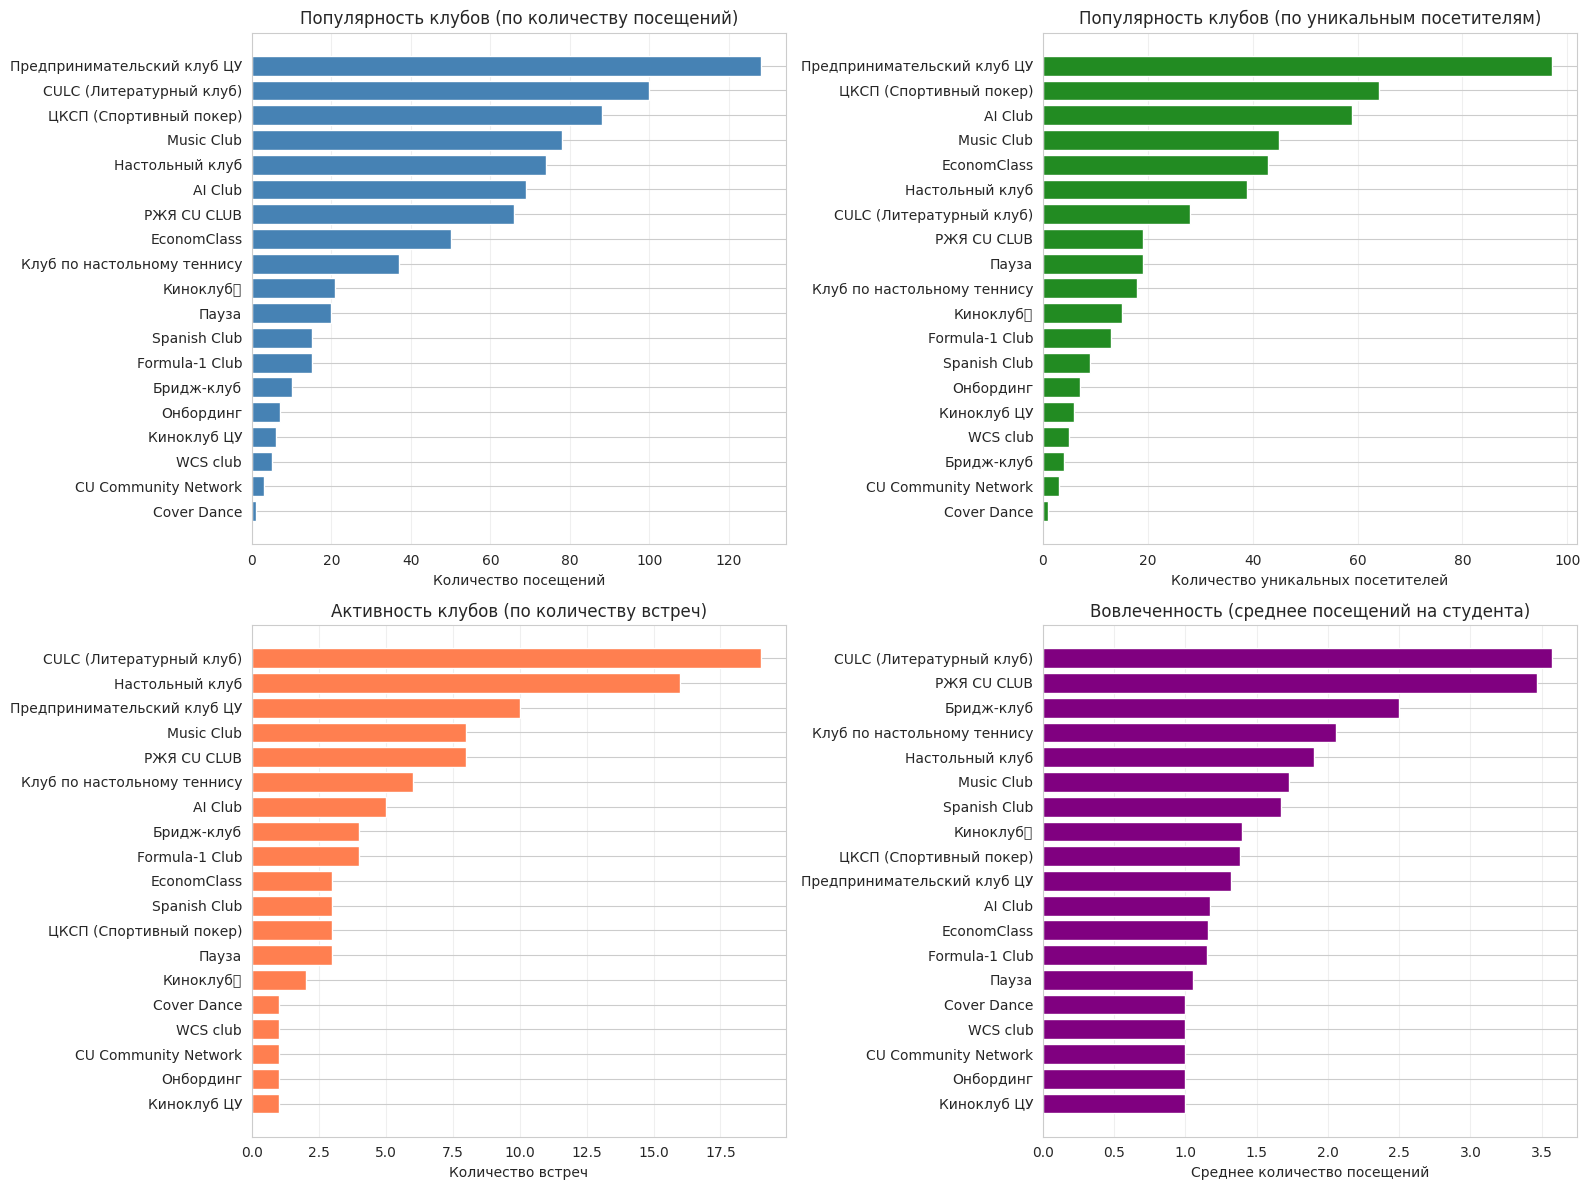

In [ ]:
# График 1: Популярность клубов по количеству посещений
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Количество посещений по клубам
ax1 = axes[0, 0]
club_stats_sorted = club_stats_df.sort_values('Количество посещений')
ax1.barh(club_stats_sorted['Клуб'], club_stats_sorted['Количество посещений'], color='steelblue')
ax1.set_xlabel('Количество посещений')
ax1.set_title('Популярность клубов (по количеству посещений)')
ax1.grid(axis='x', alpha=0.3)

# 2. Уникальные посетители по клубам
ax2 = axes[0, 1]
club_stats_sorted = club_stats_df.sort_values('Уникальные посетители')
ax2.barh(club_stats_sorted['Клуб'], club_stats_sorted['Уникальные посетители'], color='forestgreen')
ax2.set_xlabel('Количество уникальных посетителей')
ax2.set_title('Популярность клубов (по уникальным посетителям)')
ax2.grid(axis='x', alpha=0.3)

# 3. Количество встреч по клубам
ax3 = axes[1, 0]
club_stats_sorted = club_stats_df.sort_values('Количество встреч')
ax3.barh(club_stats_sorted['Клуб'], club_stats_sorted['Количество встреч'], color='coral')
ax3.set_xlabel('Количество встреч')
ax3.set_title('Активность клубов (по количеству встреч)')
ax3.grid(axis='x', alpha=0.3)

# 4. Среднее посещений на студента
ax4 = axes[1, 1]
club_stats_sorted = club_stats_df.sort_values('Среднее посещений на студента')
ax4.barh(club_stats_sorted['Клуб'], club_stats_sorted['Среднее посещений на студента'], color='purple')
ax4.set_xlabel('Среднее количество посещений')
ax4.set_title('Вовлеченность (среднее посещений на студента)')
ax4.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

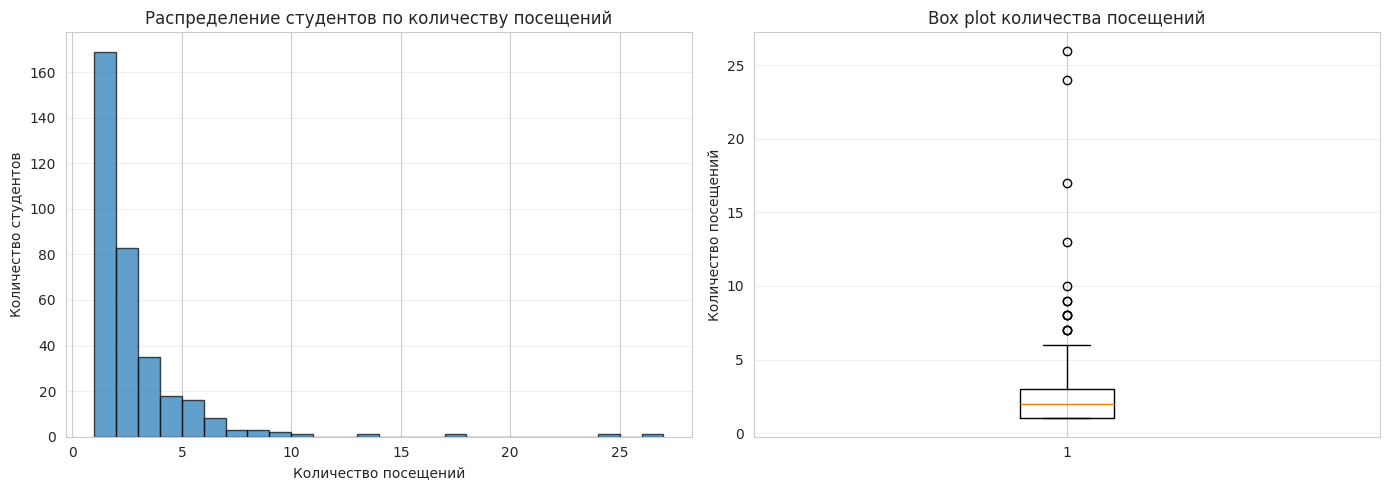

In [ ]:
# График 2: Распределение студентов по количеству посещений
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограмма посещений
ax1 = axes[0]
visit_counts = pivot_df['Общее количество посещений']
ax1.hist(visit_counts, bins=range(1, visit_counts.max() + 2), edgecolor='black', alpha=0.7)
ax1.set_xlabel('Количество посещений')
ax1.set_ylabel('Количество студентов')
ax1.set_title('Распределение студентов по количеству посещений')
ax1.grid(axis='y', alpha=0.3)

# Box plot
ax2 = axes[1]
ax2.boxplot(visit_counts, vert=True)
ax2.set_ylabel('Количество посещений')
ax2.set_title('Box plot количества посещений')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

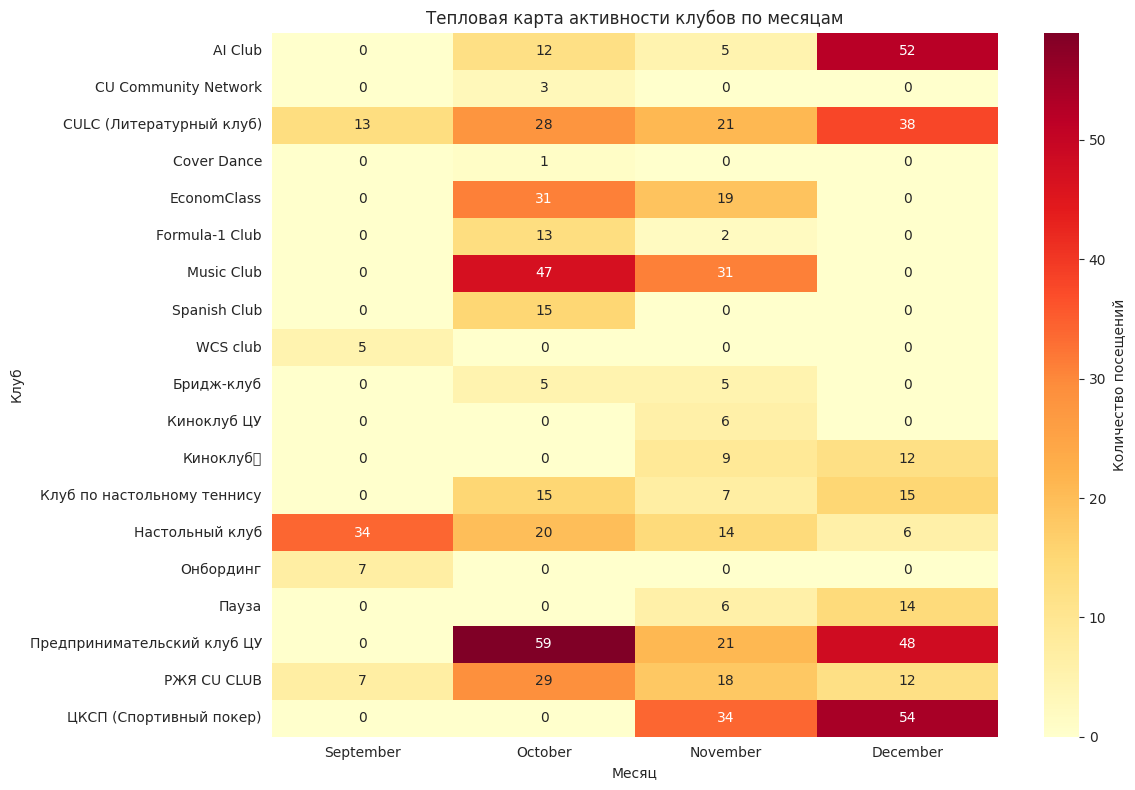

In [ ]:
# График 3: Тепловая карта активности клубов по месяцам
# Извлечение месяца из даты
df_filtered['month'] = pd.to_datetime(df_filtered['event_date']).dt.month_name()
df_filtered['month_num'] = pd.to_datetime(df_filtered['event_date']).dt.month

# Создание сводной таблицы по месяцам
monthly_pivot = df_filtered.pivot_table(
    index='club_name',
    columns='month',
    values='event_id',
    aggfunc='count',
    fill_value=0
)


month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_pivot = monthly_pivot.reindex(columns=[m for m in month_order if m in monthly_pivot.columns])

plt.figure(figsize=(12, 8))
sns.heatmap(monthly_pivot, annot=True, fmt='d', cmap='YlOrRd', cbar_kws={'label': 'Количество посещений'})
plt.title('Тепловая карта активности клубов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Клуб')
plt.tight_layout()
plt.show()

## 6. Топ-студенты по активности

In [ ]:
# Топ-20 самых активных студентов
print("Топ-20 самых активных студентов:")
print("=" * 80)

top_students = pivot_df.head(20).copy()
for idx, row in top_students.iterrows():
    print(f"\n{idx}:")
    print(f"   Общее посещений: {row['Общее количество посещений']}")

    # Клубы, которые посещал студент
    active_clubs = []
    for club in clubs:
        if club in row and row[club] > 0:
            active_clubs.append(f"{club}: {row[club]}")

    if active_clubs:
        print(f"   Клубы: {', '.join(active_clubs)}")
    print("-" * 80)

Топ-20 самых активных студентов:

Черникова Варвара Денисовна:
   Общее посещений: 26
   Клубы: CULC (Литературный клуб): 16, Бридж-клуб: 3, Настольный клуб: 1, РЖЯ CU CLUB: 6
--------------------------------------------------------------------------------

Ивашкин Иван Васильевич:
   Общее посещений: 24
   Клубы: CULC (Литературный клуб): 14, Бридж-клуб: 2, Настольный клуб: 1, РЖЯ CU CLUB: 7
--------------------------------------------------------------------------------

Советов Артём Александрович:
   Общее посещений: 17
   Клубы: CULC (Литературный клуб): 15, Настольный клуб: 2
--------------------------------------------------------------------------------

Майстренко Дарья Олеговна:
   Общее посещений: 13
   Клубы: CULC (Литературный клуб): 4, Cover Dance: 1, WCS club: 1, Настольный клуб: 1, Пауза: 2, РЖЯ CU CLUB: 4
--------------------------------------------------------------------------------

Власов Андрей Михайлович:
   Общее посещений: 10
   Клубы: CULC (Литературный клуб):

## 7. Анализ пересечения клубов (какие студенты ходят в несколько клубов)

In [ ]:
# Расчет количества клубов, которые посещает каждый студент
clubs_per_student = []
for idx, row in pivot_df.iterrows():
    club_count = 0
    for club in clubs:
        if club in row and row[club] > 0:
            club_count += 1
    clubs_per_student.append(club_count)

pivot_df_copy = pivot_df.copy()
pivot_df_copy['Количество клубов'] = clubs_per_student

# Статистика по количеству клубов
print("Статистика по количеству клубов на одного студента:")
print(f"Среднее количество клубов: {pivot_df_copy['Количество клубов'].mean():.2f}")
print(f"Медиана: {pivot_df_copy['Количество клубов'].median():.2f}")
print(f"Максимум: {pivot_df_copy['Количество клубов'].max()}")

print("\nРаспределение по количеству клубов:")
print(pivot_df_copy['Количество клубов'].value_counts().sort_index())

# Топ студенты, посещающие несколько клубов
print("\nТоп-10 студентов, посещающих несколько клубов:")
multi_club_students = pivot_df_copy[pivot_df_copy['Количество клубов'] > 1].sort_values(
    ['Количество клубов', 'Общее количество посещений'], ascending=[False, False]
)
multi_club_students[['Общее количество посещений', 'Количество клубов']].head(10)

Статистика по количеству клубов на одного студента:
Среднее количество клубов: 1.44
Медиана: 1.00
Максимум: 6

Распределение по количеству клубов:
Количество клубов
1    229
2     85
3     20
4      6
5      1
6      1
Name: count, dtype: int64

Топ-10 студентов, посещающих несколько клубов:


club_name,Общее количество посещений,Количество клубов
фио,,
Майстренко Дарья Олеговна,13,6
Чупин Егор Леонидович,7,5
Черникова Варвара Денисовна,26,4
Ивашкин Иван Васильевич,24,4
Сорокина Анна Алексеевна,9,4
Завьялова Юлия Андреевна,9,4
Палкина Ксения Александровна,7,4
Логинов Сергей Александрович,5,4
Власов Андрей Михайлович,10,3


## 8. Экспорт результатов

In [ ]:
# Создание Excel файла с несколькими листами
excel_file = './club_activity_analysis.xlsx'

with pd.ExcelWriter(excel_file, engine='openpyxl') as writer:
    # Лист 1: Сводная таблица
    pivot_df.to_excel(writer, sheet_name='Студенты')

    # Лист 2: Статистика по клубам
    club_stats_df.to_excel(writer, sheet_name='Статистика клубов', index=False)

    # Лист 3: Основные метрики
    metrics_df = pd.DataFrame({
        'Метрика': [
            'Студентов всего в вузе',
            'Уникальных посетителей',
            'Количество посещений',
            'Количество встреч',
            'Количество клубов',
            'Рейтинг участия (%)',
            'Среднее посещений на участника',
            'Посещений на одно мероприятие'
        ],
        'Значение': [
            TOTAL_STUDENTS_UNIVERSITY,
            unique_students,
            total_visits,
            total_events,
            total_clubs,
            f'{participation_rate:.2f}%',
            f'{avg_visits_per_participant:.2f}',
            f'{total_visits / total_events:.2f}'
        ]
    })
    metrics_df.to_excel(writer, sheet_name='Основные метрики', index=False)

print(f"Excel файл сохранен: {excel_file}")

Excel файл сохранен: ./club_activity_analysis.xlsx


## 9. Итоговый отчет

In [ ]:
print("\n" + "=" * 80)
print("ИТОГОВЫЙ ОТЧЕТ ПО КЛУБНОЙ ДЕЯТЕЛЬНОСТИ")
print("=" * 80)

print(f"\n📊 ОБЩИЕ ПОКАЗАТЕЛИ:")
print(f"   • Всего студентов в вузе: {TOTAL_STUDENTS_UNIVERSITY}")
print(f"   • Участвуют в клубной деятельности: {unique_students} ({participation_rate:.1f}%)")
print(f"   • Не участвуют: {TOTAL_STUDENTS_UNIVERSITY - unique_students} ({100 - participation_rate:.1f}%)")

print(f"\n🎯 АКТИВНОСТЬ:")
print(f"   • Всего посещений: {total_visits}")
print(f"   • Всего мероприятий: {total_events}")
print(f"   • Всего клубов: {total_clubs}")
print(f"   • Среднее посещений на студента: {avg_visits_per_participant:.1f}")
print(f"   • Среднее посещений на мероприятие: {total_visits / total_events:.1f}")

print(f"\n🏆 ТОП-3 КЛУБА (по посещениям):")
for i, (_, row) in enumerate(club_stats_df.head(3).iterrows(), 1):
    print(f"   {i}. {row['Клуб']}: {row['Количество посещений']} посещений, {row['Уникальные посетители']} уникальных посетителей")

most_active = pivot_df.index[0]
print(f"\n⭐ САМЫЙ АКТИВНЫЙ СТУДЕНТ:")
print(f"   {most_active}: {pivot_df.loc[most_active, 'Общее количество посещений']} посещений")


ИТОГОВЫЙ ОТЧЕТ ПО КЛУБНОЙ ДЕЯТЕЛЬНОСТИ

📊 ОБЩИЕ ПОКАЗАТЕЛИ:
   • Всего студентов в вузе: 1677
   • Участвуют в клубной деятельности: 342 (20.4%)
   • Не участвуют: 1335 (79.6%)

🎯 АКТИВНОСТЬ:
   • Всего посещений: 793
   • Всего мероприятий: 99
   • Всего клубов: 19
   • Среднее посещений на студента: 2.3
   • Среднее посещений на мероприятие: 8.0

🏆 ТОП-3 КЛУБА (по посещениям):
   1. Предпринимательский клуб ЦУ: 128 посещений, 97 уникальных посетителей
   2. CULC (Литературный клуб): 100 посещений, 28 уникальных посетителей
   3. ЦКСП (Спортивный покер): 88 посещений, 64 уникальных посетителей

⭐ САМЫЙ АКТИВНЫЙ СТУДЕНТ:
   Черникова Варвара Денисовна: 26 посещений
